## CME FEB 2026

In [13]:
import pandas as pd
import numpy as np

cme_feb_2026 = pd.read_csv("../../data/raw/CME/CME_FEB_2026.csv")
cme_feb_2026 = cme_feb_2026.reset_index(drop = True)
cme_feb_2026["time"] = pd.to_datetime(cme_feb_2026["time"],unit="s") 

In [14]:
cme_feb_2026

,time,open,high,low,close,Volume
0,2025-09-26 19:46:00,96.400,96.400,96.400,96.400,32
1,2025-09-26 19:55:00,96.400,96.400,96.400,96.400,423
2,2025-09-26 20:01:00,96.405,96.405,96.405,96.405,705
3,2025-09-26 20:02:00,96.405,96.405,96.405,96.405,39
4,2025-09-26 20:03:00,96.405,96.405,96.405,96.405,9
...,...,...,...,...,...,...
19994,2026-02-27 21:05:00,96.360,96.360,96.360,96.360,1
19995,2026-02-27 21:17:00,96.360,96.360,96.360,96.360,2
19996,2026-02-27 21:22:00,96.360,96.360,96.360,96.360,8
19997,2026-02-27 21:28:00,96.360,96.360,96.360,96.360,1


## CME MAR 2026

In [15]:
cme_mar_2026 = pd.read_csv("../../data/raw/CME/CME_MAR_2026.csv")
cme_mar_2026 = cme_mar_2026.reset_index(drop = True)
cme_mar_2026["time"] = pd.to_datetime(cme_mar_2026["time"],unit="s") 

In [16]:
cme_mar_2026

,time,open,high,low,close,Volume
0,2025-09-19 18:32:00,96.5300,96.5300,96.5300,96.5300,1
1,2025-09-19 18:38:00,96.5350,96.5350,96.5350,96.5350,1
2,2025-09-19 18:49:00,96.5350,96.5350,96.5350,96.5350,1
3,2025-09-19 18:57:00,96.5300,96.5300,96.5300,96.5300,3
4,2025-09-19 18:58:00,96.5300,96.5300,96.5300,96.5300,78
...,...,...,...,...,...,...
19994,2026-03-31 19:14:00,96.3600,96.3600,96.3600,96.3600,4
19995,2026-03-31 19:41:00,96.3600,96.3600,96.3600,96.3600,11
19996,2026-03-31 19:51:00,96.3600,96.3600,96.3600,96.3600,9
19997,2026-03-31 20:42:00,96.3575,96.3575,96.3575,96.3575,31


## Merge and then calculate probabilities

In [17]:
feb = cme_feb_2026.copy()
feb["time"] = pd.to_datetime(feb["time"], unit="s")
feb = feb.sort_values("time").set_index("time")

feb = feb.add_suffix("_feb_2026")

mar = cme_mar_2026.copy()
mar["time"] = pd.to_datetime(mar["time"], unit="s")
mar = mar.sort_values("time").set_index("time")

mar = mar.add_suffix("_mar_2026")

feb_aligned = feb.reindex(mar.index, method="ffill")


final_df = pd.concat([mar, feb_aligned], axis=1)
final_df = final_df.reset_index()

In [18]:
final_df = final_df.dropna()

In [19]:
final_df

,time,open_mar_2026,high_mar_2026,low_mar_2026,close_mar_2026,Volume_mar_2026,open_feb_2026,high_feb_2026,low_feb_2026,close_feb_2026,Volume_feb_2026
1062,2025-09-26 20:01:00,96.4450,96.4450,96.4450,96.4450,52,96.405,96.405,96.405,96.405,705.0
1063,2025-09-26 20:02:00,96.4450,96.4450,96.4450,96.4450,1,96.405,96.405,96.405,96.405,39.0
1064,2025-09-26 20:04:00,96.4450,96.4450,96.4450,96.4450,3,96.405,96.405,96.405,96.405,29.0
1065,2025-09-26 20:16:00,96.4400,96.4400,96.4400,96.4400,11,96.400,96.400,96.400,96.400,5.0
1066,2025-09-26 20:23:00,96.4450,96.4450,96.4450,96.4450,2,96.405,96.405,96.405,96.405,52.0
...,...,...,...,...,...,...,...,...,...,...,...
19994,2026-03-31 19:14:00,96.3600,96.3600,96.3600,96.3600,4,96.360,96.360,96.360,96.360,5.0
19995,2026-03-31 19:41:00,96.3600,96.3600,96.3600,96.3600,11,96.360,96.360,96.360,96.360,5.0
19996,2026-03-31 19:51:00,96.3600,96.3600,96.3600,96.3600,9,96.360,96.360,96.360,96.360,5.0
19997,2026-03-31 20:42:00,96.3575,96.3575,96.3575,96.3575,31,96.360,96.360,96.360,96.360,5.0


## Calculating Implied Probabilities

In [20]:
meeting_day = 18
days_in_march = 31

N = meeting_day           
M = days_in_march - N        

imp_df = pd.DataFrame()
imp_df["time"] = final_df["time"].copy()


imp_df["effr_avg_feb"] = 100 - final_df["close_feb_2026"]
imp_df["effr_avg_mar"] = 100 - final_df["close_mar_2026"]


imp_df["effr_end_feb"] = imp_df["effr_avg_feb"]
imp_df["effr_start_mar"] = imp_df["effr_end_feb"]
imp_df["volume"] = final_df["Volume_mar_2026"]


In [21]:
imp_df

,time,effr_avg_feb,effr_avg_mar,effr_end_feb,effr_start_mar,volume
1062,2025-09-26 20:01:00,3.595,3.5550,3.595,3.595,52
1063,2025-09-26 20:02:00,3.595,3.5550,3.595,3.595,1
1064,2025-09-26 20:04:00,3.595,3.5550,3.595,3.595,3
1065,2025-09-26 20:16:00,3.600,3.5600,3.600,3.600,11
1066,2025-09-26 20:23:00,3.595,3.5550,3.595,3.595,2
...,...,...,...,...,...,...
19994,2026-03-31 19:14:00,3.640,3.6400,3.640,3.640,4
19995,2026-03-31 19:41:00,3.640,3.6400,3.640,3.640,11
19996,2026-03-31 19:51:00,3.640,3.6400,3.640,3.640,9
19997,2026-03-31 20:42:00,3.640,3.6425,3.640,3.640,31


In [22]:
imp_df["effr_end_mar"] = (
    imp_df["effr_avg_mar"] - (N / (N + M)) * imp_df["effr_start_mar"]
) / (M / (N + M))

In [23]:
imp_df["delta_effr"] = imp_df["effr_end_mar"] - imp_df["effr_start_mar"]
imp_df["num_hikes"] = imp_df["delta_effr"] / 0.25

imp_df["hikes_floor"] = np.floor(imp_df["num_hikes"])
imp_df["hikes_decimal"] = imp_df["num_hikes"] - imp_df["hikes_floor"]


states = [-4, -3, -2, -1, 0, 1, 2, 3, 4]

state_to_col = {
    -4: "prob_cut_100",
    -3: "prob_cut_75",
    -2: "prob_cut_50",
    -1: "prob_cut_25",
     0: "prob_no_change",
     1: "prob_hike_25",
     2: "prob_hike_50",
     3: "prob_hike_75",
     4: "prob_hike_100"
}

for col in state_to_col.values():
    imp_df[col] = 0.0

for i, row in imp_df.iterrows():
    floor = int(row["hikes_floor"])
    decimal = row["hikes_decimal"]
    
    p_low = 1 - decimal
    p_high = decimal
    
    if floor in state_to_col:
        imp_df.at[i, state_to_col[floor]] += p_low

    if (floor + 1) in state_to_col:
        imp_df.at[i, state_to_col[floor + 1]] += p_high

In [24]:
imp_df

,time,effr_avg_feb,effr_avg_mar,effr_end_feb,effr_start_mar,volume,effr_end_mar,delta_effr,num_hikes,hikes_floor,hikes_decimal,prob_cut_100,prob_cut_75,prob_cut_50,prob_cut_25,prob_no_change,prob_hike_25,prob_hike_50,prob_hike_75,prob_hike_100
1062,2025-09-26 20:01:00,3.595,3.5550,3.595,3.595,52,3.499615,-9.538462e-02,-3.815385e-01,-1.0,0.618462,0.0,0.0,0.0,3.815385e-01,0.618462,0.000000,0.0,0.0,0.0
1063,2025-09-26 20:02:00,3.595,3.5550,3.595,3.595,1,3.499615,-9.538462e-02,-3.815385e-01,-1.0,0.618462,0.0,0.0,0.0,3.815385e-01,0.618462,0.000000,0.0,0.0,0.0
1064,2025-09-26 20:04:00,3.595,3.5550,3.595,3.595,3,3.499615,-9.538462e-02,-3.815385e-01,-1.0,0.618462,0.0,0.0,0.0,3.815385e-01,0.618462,0.000000,0.0,0.0,0.0
1065,2025-09-26 20:16:00,3.600,3.5600,3.600,3.600,11,3.504615,-9.538462e-02,-3.815385e-01,-1.0,0.618462,0.0,0.0,0.0,3.815385e-01,0.618462,0.000000,0.0,0.0,0.0
1066,2025-09-26 20:23:00,3.595,3.5550,3.595,3.595,2,3.499615,-9.538462e-02,-3.815385e-01,-1.0,0.618462,0.0,0.0,0.0,3.815385e-01,0.618462,0.000000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19994,2026-03-31 19:14:00,3.640,3.6400,3.640,3.640,4,3.640000,-8.881784e-16,-3.552714e-15,-1.0,1.000000,0.0,0.0,0.0,3.552714e-15,1.000000,0.000000,0.0,0.0,0.0
19995,2026-03-31 19:41:00,3.640,3.6400,3.640,3.640,11,3.640000,-8.881784e-16,-3.552714e-15,-1.0,1.000000,0.0,0.0,0.0,3.552714e-15,1.000000,0.000000,0.0,0.0,0.0
19996,2026-03-31 19:51:00,3.640,3.6400,3.640,3.640,9,3.640000,-8.881784e-16,-3.552714e-15,-1.0,1.000000,0.0,0.0,0.0,3.552714e-15,1.000000,0.000000,0.0,0.0,0.0
19997,2026-03-31 20:42:00,3.640,3.6425,3.640,3.640,31,3.645962,5.961538e-03,2.384615e-02,0.0,0.023846,0.0,0.0,0.0,0.000000e+00,0.976154,0.023846,0.0,0.0,0.0


In [25]:
imp_df["time"] = pd.to_datetime(imp_df["time"], utc=True)

## Filtering Based on Announcement Time

In [26]:
fomc_2026_utc = {
    "January 2026": pd.Timestamp("2026-01-28 19:00:00", tz="UTC"),   # Winter (Standard Time)
    "March 2026": pd.Timestamp("2026-03-18 18:00:00", tz="UTC"),     # Summer (Daylight Saving)
    "April 2026": pd.Timestamp("2026-04-29 18:00:00", tz="UTC"),     # Summer (Daylight Saving)
    "June 2026": pd.Timestamp("2026-06-17 18:00:00", tz="UTC"),      # Summer (Daylight Saving)
    "July 2026": pd.Timestamp("2026-07-29 18:00:00", tz="UTC"),      # Summer (Daylight Saving)1
    "September 2026": pd.Timestamp("2026-09-16 18:00:00", tz="UTC"), # Summer (Daylight Saving)
    "October 2026": pd.Timestamp("2026-10-28 18:00:00", tz="UTC"),   # Summer (Daylight Saving)
    "December 2026": pd.Timestamp("2026-12-09 19:00:00", tz="UTC"),  # Winter (Standard Time)
}

In [27]:
def filter_up_to_announcement(df, announcement_dict):

    if df.empty:
        return df
    last_timestamp = df["time"].iloc[-1]
    last_month_year = last_timestamp.strftime("%B %Y")

    if last_month_year in announcement_dict:
        cutoff_time = announcement_dict[last_month_year]
        filtered_df = df[df["time"] <= cutoff_time]
        return filtered_df
    else:
        print(
            f"Warning: '{last_month_year}' not found in the announcement dictionary"
        )
        return df

In [ ]:
imp_df_fil = filter_up_to_announcement(imp_df,fomc_2026_utc)

## Export the Data as a CSV

In [28]:
import os
DATA_DIR = "../../data/processed/CME_implied_probabilities"
filename = "CME_IMP_MAR_2026.csv"
path = os.path.join(DATA_DIR, filename)
imp_df.to_csv(path,index=False)

## Visualization 

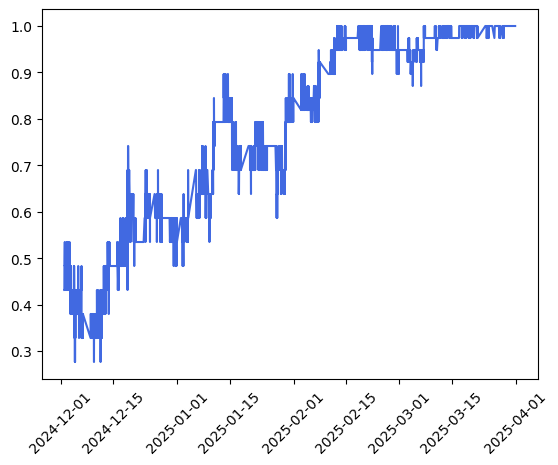

In [17]:
import matplotlib.pyplot as plt

plt.plot(imp_df["time"],imp_df['prob_no_change'], color='royalblue', linewidth=1.5)
plt.xticks(rotation=45)
plt.show()